# Initialization

In [1]:
#Import all the UTILITY functions
from UTILITY_quickstart import *

In [2]:
#Load a reference configuration
importedDefaultSettings = loadConfig("setLattice_configs/2024-10-22_oneBunch_baseline3.yml")

#Initialize tao object; tell it to run IMPACT-T to generate the initial beam
tao = initializeTao(
    csrTF = False,

    #Commands to start and run IMPACT-T. Overwriting some default settings, just to demonstrate
    runImpactTF = True,
    numMacroParticles = 1e4,
    impactChargepC = 2000,
    impactGridCount = 8
    # These settings give a very low fidelity simulation, but are selected to give a quick demo
)

Environment set to:  /Users/nmajik/Documents/SLAC/FACET2-S2E
CSR off
Overwriting lattice with setLattice() defaults
No defaults file provided to setLattice(). Using /Users/nmajik/Documents/SLAC/FACET2-S2E/setLattice_configs/defaults.yml
Running Impact
	 Impact: Autophasing
	 Impact: Distgen
	 Impact: Tracking
Running Impact-T in /Users/nmajik/Documents/SLAC/FACET2-S2E/impact/tmpfb_3f1aq
/opt/homebrew/anaconda3/envs/bmad/bin/ImpactTexe
writing 10000 particles to /Users/nmajik/Documents/SLAC/FACET2-S2E/impact/tmpfb_3f1aq/partcl.data
Cathode start with cathode_kinetic_energy_ref = 1.0 eV
Cathode start: Replaced Np with 10000 according to initial particles
Cathode start: Replaced Bkenergy with 1.0 according to initial particles
Cathode start: Replaced Temission with 6.97502773839391e-12 according to initial particles
Cathode start: Replaced Tini with -3.4942219079267073e-12 according to initial particles
Setting total charge to 1.9999999999999997e-09 C
 !-----------------------------------

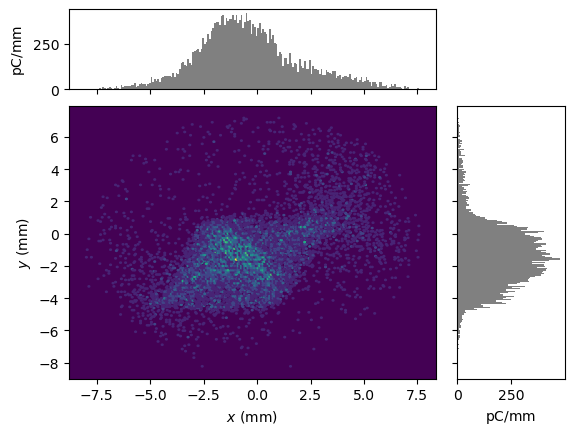

ParticleGroup with 10000 particles with total charge 1.9999999999999997e-09 C


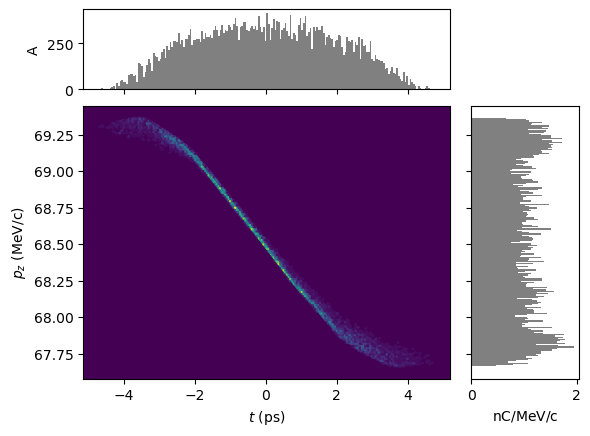

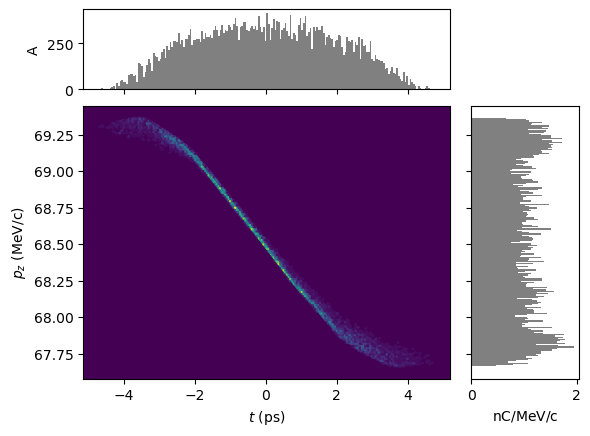

In [3]:
#Examine the beam IMPACT-T produced
P = ParticleGroup("./beams/activeBeamFile.h5")


display(plotMod(P, 'x', 'y',  bins=200));
plt.clf()

print(P)

#Plot the longitudinal phase space
display(plotMod(P, 't', 'pz',  bins=200));

# Track IMPACT-T beam to end

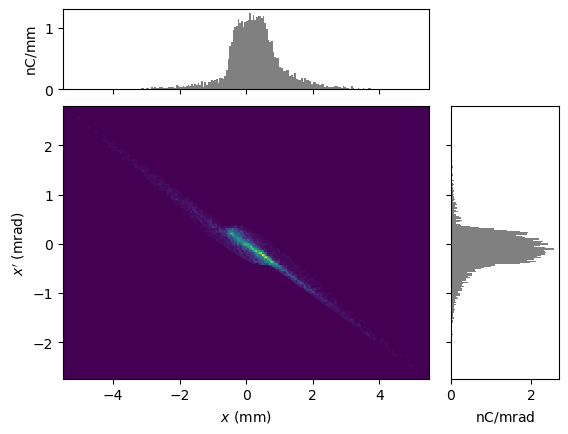

ParticleGroup with 10000 particles with total charge 1.9999999999999997e-09 C


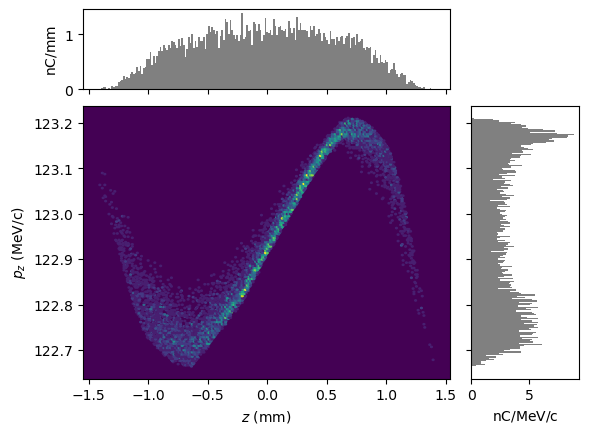

In [5]:
tao.cmd("set beam add_saved_at = BPM10511") 

#Set lattice to the loaded config
setLattice(tao, **importedDefaultSettings)

#Track the beam from start to end
trackBeam(tao, **importedDefaultSettings)



#Get the beam at element "PENT"
P =  getBeamAtElement(tao, "BPM10511")

#Plot the x-y projection of the beam at that location
display(plotMod(P, 'x', 'xp',  bins=200));
plt.clf()

print(P)

#Plot the longitudinal phase space
display(plotMod(P, 'z', 'pz',  bins=200));

In [6]:
#Initialize tao object; tell it to run IMPACT-T to generate the initial beam
tao = initializeTao(
    csrTF = False,

    #Commands to start and run IMPACT-T. Overwriting some default settings, just to demonstrate
    runImpactTF = True,
    numMacroParticles = 1e4,
    impactChargepC = 1000,
    impactGridCount = 8
    # These settings give a very low fidelity simulation, but are selected to give a quick demo
)

Environment set to:  /Users/nmajik/Documents/SLAC/FACET2-S2E
CSR off
Overwriting lattice with setLattice() defaults
No defaults file provided to setLattice(). Using /Users/nmajik/Documents/SLAC/FACET2-S2E/setLattice_configs/defaults.yml
Running Impact
	 Impact: Autophasing
	 Impact: Distgen
	 Impact: Tracking
Running Impact-T in /Users/nmajik/Documents/SLAC/FACET2-S2E/impact/tmp51m_m08q
/opt/homebrew/anaconda3/envs/bmad/bin/ImpactTexe
writing 10000 particles to /Users/nmajik/Documents/SLAC/FACET2-S2E/impact/tmp51m_m08q/partcl.data
Cathode start with cathode_kinetic_energy_ref = 1.0 eV
Cathode start: Replaced Np with 10000 according to initial particles
Cathode start: Replaced Bkenergy with 1.0 according to initial particles
Cathode start: Replaced Temission with 6.97502773839391e-12 according to initial particles
Cathode start: Replaced Tini with -3.4942219079267073e-12 according to initial particles
Setting total charge to 9.999999999999999e-10 C
 !------------------------------------

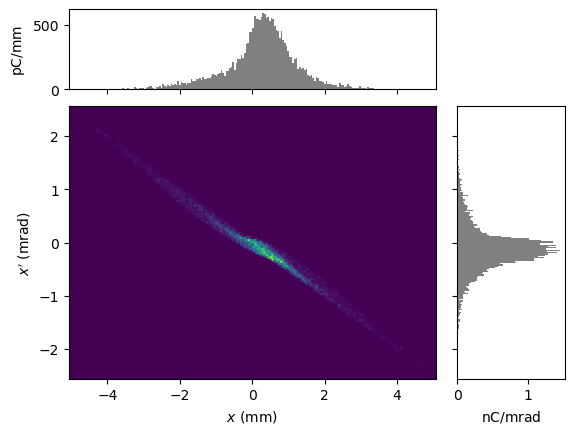

ParticleGroup with 10000 particles with total charge 9.999999999999999e-10 C


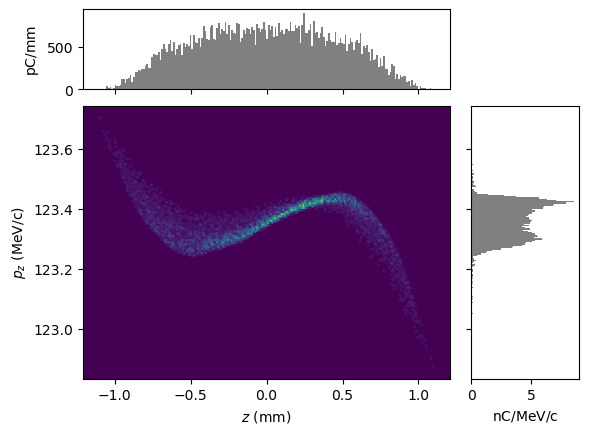

In [8]:

tao.cmd("set beam add_saved_at = BPM10511") 

#Set lattice to the loaded config
setLattice(tao, **importedDefaultSettings)

#Track the beam from start to end
trackBeam(tao, trackEnd = "BPM10511", **importedDefaultSettings)



#Get the beam at element "PENT"
P =  getBeamAtElement(tao, "BPM10511")

#Plot the x-y projection of the beam at that location
display(plotMod(P, 'x', 'xp',  bins=200));
plt.clf()

print(P)

#Plot the longitudinal phase space
display(plotMod(P, 'z', 'pz',  bins=200));

In [9]:
?calcBMAG

Signature: calcBMAG(b0, a0, b, a)
Docstring: <no docstring>
File:      ~/Documents/SLAC/FACET2-S2E/UTILITY_quickstart.py
Type:      function

In [10]:
calcBMAG( 1.17, 0.35, 1.17, -0.88 ) 

1.75645

In [11]:
?launchTwissCorrection

Signature:
launchTwissCorrection(
    tao,
    evalElement=None,
    targetBetaX=None,
    targetAlphaX=None,
    targetBetaY=None,
    targetAlphaY=None,
)
Docstring:
This function will update the BEGINNING twiss values (set in bmad/models/f2_elec/f2_elec.lat.bmad, e.g. BEGINNING[BETA_A] =  1.39449126865854395E-001) to achieve an arbitrary match at an arbitrary element.

If no element is specified, the function will create the default golden lattice match at PR10571
File:      ~/Documents/SLAC/FACET2-S2E/UTILITY_quickstart.py
Type:      function

In [14]:
launchTwissCorrection(tao)

No evalElement provided. Assuming golden lattice PR10571
Optimization Results:
Optimal Parameters: [35.03550563 16.56305755 24.6586748  17.62176522]
Objective Function Value at Optimal Parameters: 2.0959764005380888e-11
Number of Iterations: 390
Converged: True


In [15]:
tao.ele_twiss("BPM10511")

{'mode_flip': False,
 'beta_a': 3.59659679914439,
 'alpha_a': 0.912085612069232,
 'gamma_a': 0.509342655306678,
 'phi_a': 5.6274809389577,
 'eta_a': 6.25641848183036e-17,
 'etap_a': -1.13239391183742e-16,
 'beta_b': 1.8129956925775,
 'alpha_b': -1.80808508987985,
 'gamma_b': 2.35476107843171,
 'phi_b': 7.45069669623719,
 'eta_b': -1.86776446260414e-36,
 'etap_b': -1.61118617310452e-36,
 'eta_x': 6.25641848183036e-17,
 'etap_x': -1.13239391183742e-16,
 'eta_y': -9.18879217580184e-37,
 'etap_y': -7.29778903441792e-37}

In [16]:
tao.ele_twiss("PR10571")

{'mode_flip': False,
 'beta_a': 5.73666798930038,
 'alpha_a': -2.14411302427746,
 'gamma_a': 0.975691929760578,
 'phi_a': 7.39745882110263,
 'eta_a': -5.87031399991309e-16,
 'etap_a': -1.89608272477441e-16,
 'beta_b': 2.57530239138964,
 'alpha_b': 0.0101614433444807,
 'gamma_b': 0.388344008950026,
 'phi_b': 8.38198357250854,
 'eta_b': 2.10710811419259e-36,
 'etap_b': 2.76287374701647e-36,
 'eta_x': -5.87031399991309e-16,
 'etap_x': -1.89608272477441e-16,
 'eta_y': 3.80359538562861e-36,
 'etap_y': 1.57283821606298e-36}

In [17]:
launchTwissCorrection( tao, evalElement = "BPM10511", targetBetaX = 1.17, targetAlphaX = 0.35, targetBetaY = 1.8, targetAlphaY = -1.8 )

Optimization Results:
Optimal Parameters: [45.50573384 20.19399653 24.69601367 17.65699885]
Objective Function Value at Optimal Parameters: 2.7665478821131638e-09
Number of Iterations: 475
Converged: False


In [18]:
tao.ele_twiss("BPM10511")

{'mode_flip': False,
 'beta_a': 1.17004151029919,
 'alpha_a': 0.350024498893426,
 'gamma_a': 0.959382329553894,
 'phi_a': 5.06641831796373,
 'eta_a': 6.25641848183036e-17,
 'etap_a': -1.13239391183742e-16,
 'beta_b': 1.80002062697829,
 'alpha_b': -1.79999578396741,
 'gamma_b': 2.35552013057659,
 'phi_b': 7.45740257264641,
 'eta_b': -1.86776446260414e-36,
 'etap_b': -1.61118617310452e-36,
 'eta_x': 6.25641848183036e-17,
 'etap_x': -1.13239391183742e-16,
 'eta_y': -9.18879217580184e-37,
 'etap_y': -7.29778903441792e-37}

In [19]:
tao.ele_twiss("PR10571")

{'mode_flip': False,
 'beta_a': 17.1834122941713,
 'alpha_a': -5.93673561601017,
 'gamma_a': 2.10929174915381,
 'phi_a': 6.75563196231323,
 'eta_a': -5.87031399991309e-16,
 'etap_a': -1.89608272477441e-16,
 'beta_b': 2.59269271718725,
 'alpha_b': 0.00473509758086612,
 'gamma_b': 0.385708038025424,
 'phi_b': 8.38899366546867,
 'eta_b': 2.10710811419259e-36,
 'etap_b': 2.76287374701647e-36,
 'eta_x': -5.87031399991309e-16,
 'etap_x': -1.89608272477441e-16,
 'eta_y': 3.80359538562861e-36,
 'etap_y': 1.57283821606298e-36}

In [20]:
launchTwissCorrection( tao, evalElement = "BPM10511", targetBetaX = 1.17, targetAlphaX = -0.88, targetBetaY = 1.8, targetAlphaY = -1.8 )

Optimization Results:
Optimal Parameters: [102.59389775  45.86964617  23.42422021  16.89136799]
Objective Function Value at Optimal Parameters: 0.1572559873095117
Number of Iterations: 498
Converged: False


In [21]:
tao.ele_twiss("BPM10511")

{'mode_flip': False,
 'beta_a': 1.08701094213904,
 'alpha_a': -0.506457083614859,
 'gamma_a': 1.15592100211163,
 'phi_a': 5.5780805450163,
 'eta_a': 6.25641848183036e-17,
 'etap_a': -1.13239391183742e-16,
 'beta_b': 1.71839012923319,
 'alpha_b': -1.86460899470484,
 'gamma_b': 2.6052097407775,
 'phi_b': 7.60568053378695,
 'eta_b': -1.86776446260414e-36,
 'etap_b': -1.61118617310452e-36,
 'eta_x': 6.25641848183036e-17,
 'etap_x': -1.13239391183742e-16,
 'eta_y': -9.18879217580184e-37,
 'etap_y': -7.29778903441792e-37}

In [22]:
tao.ele_twiss("PR10571")

{'mode_flip': False,
 'beta_a': 27.7214906173849,
 'alpha_a': -8.66451134385341,
 'gamma_a': 2.74421595424802,
 'phi_a': 6.52412224091013,
 'eta_a': -5.87031399991309e-16,
 'etap_a': -1.89608272477441e-16,
 'beta_b': 3.03066364331275,
 'alpha_b': -0.00749493274932553,
 'gamma_b': 0.329979269135844,
 'phi_b': 8.46860045623868,
 'eta_b': 2.10710811419259e-36,
 'etap_b': 2.76287374701647e-36,
 'eta_x': -5.87031399991309e-16,
 'etap_x': -1.89608272477441e-16,
 'eta_y': 3.80359538562861e-36,
 'etap_y': 1.57283821606298e-36}